### Лабораторная работа №5 "Базовый функционал библиотеки Pytorch и реализация градиентного спуска для линейной регрессии"

In [21]:
import torch
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})

**1.** Пример с квадратичной функцией

Необхдимые функции

In [22]:
def loss_func(y,y_pred):
    """Функция потерь"""
    return torch.mean((y - y_pred) ** 2)

In [23]:
def func_x2(x, theta):
    """Квадратное уравнение"""
    return theta[0] + theta[1] * x + theta[2] * x ** 2

In [24]:
def plot_rez(x, y, y_pred, feature=1):
    """Вывод результатов"""
    plt.figure(figsize=(6, 3))
    if len(x.shape) > 1:
        x = x[:, feature]
    plt.scatter(x, y, label='y_true', c='g')
    plt.plot(x, y_pred, label='y_pred', c='r')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.show()

In [25]:
def plot_peds_vs_targets(y, y_pred):
    """Сравнение предсказаний и разметки"""
    plt.figure(figsize=(6, 6))
    plt.scatter(y, y, c='g')
    plt.scatter(y, y_pred, c='r')
    plt.legend(['targets', 'predictions'])
    plt.xlabel('target y')
    plt.ylabel('predicted y')
    plt.show()

In [26]:
def plot_loss(loss_value):
    """Вывод результатов"""
    plt.figure(figsize=(6, 3))
    plt.plot(loss_value, label = 'y_pred')
    plt.ylabel('loss')
    plt.xlabel('Iteration')
    plt.legend()
    plt.yscale('log')
    plt.show()

In [27]:
def train_proc(X, theta, y, forward_fcn, lr=0.001, num_iter=10):
    """Процесс обучения"""
    loss_value = []
    
    for itr in range(num_iter):
        theta.grad = None # Обнуление градиента     
        loss = loss_func(y, forward_fcn(X, theta)) # Прямой проход искомой функции и расчет функции потерь
        loss.backward() # Расчет градиентов
        loss_value.append(loss.item())
        theta.data -= lr * theta.grad.data # Выполнение градиентного спуска
    
    return theta.data, loss_value

Инициализация входов, выходов и весов

In [28]:
x1, xn, n = 2, 7, 20
theta_true = torch.tensor([3, 1, 3])

X = torch.linspace(x1, xn, n)
y = func_x2(X, theta_true) + torch.randn(X.shape[0]) * 2
theta = torch.rand(3,1).requires_grad_()

Обучение

MSE optimal = 5.21382


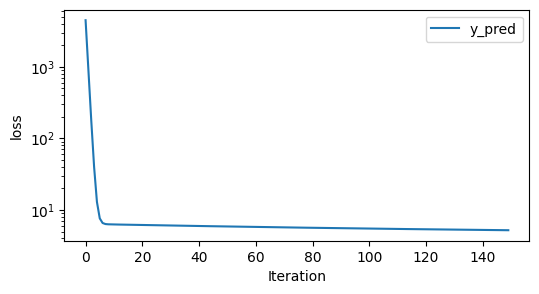

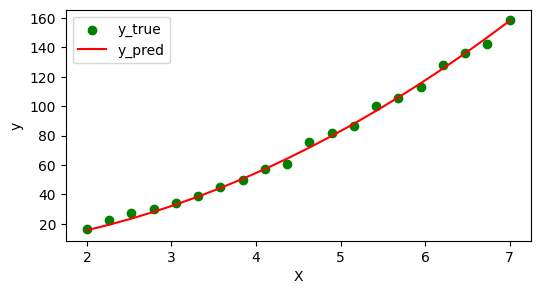

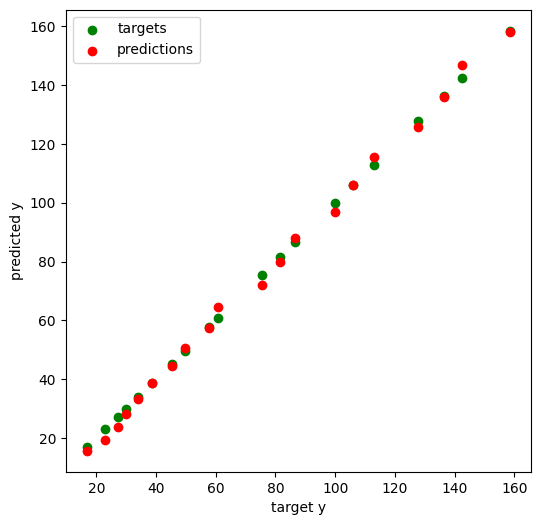

In [29]:
theta_opt, loss_value = train_proc(X, theta, y, forward_fcn=func_x2, lr=0.001, num_iter=150)
y_pred = func_x2(X, theta_opt)
mse_opt = loss_func(y, y_pred)
print('MSE optimal = %.5f' % mse_opt.item())
plot_loss(loss_value)
plot_rez(X, y, y_pred)
plot_peds_vs_targets(y, y_pred)

**2.** Добавтье [датасет](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who/data) в рабочую директорию. Добавьте нормализацию, обработку качественных признаков и разбиение на выборки (train_test_split работает и с тензорами).

In [31]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


def normalization(X):
    return (X - X.mean()) / X.std()

df = fetch_california_housing(as_frame=True)

X = normalization(df.data.copy())
y = df.target

display(X)
display(y)

X = torch.tensor(X.to_numpy())
y = torch.tensor(y.to_numpy())

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.6)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=0.5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344709,0.982119,0.628544,-0.153754,-0.974405,-0.049595,1.052523,-1.327803
1,2.332181,-0.607004,0.327033,-0.263329,0.861418,-0.092510,1.043159,-1.322812
2,1.782656,1.856137,1.155592,-0.049015,-0.820757,-0.025842,1.038478,-1.332794
3,0.932945,1.856137,0.156962,-0.049832,-0.766010,-0.050328,1.038478,-1.337785
4,-0.012881,1.856137,0.344702,-0.032905,-0.759828,-0.085614,1.038478,-1.337785
...,...,...,...,...,...,...,...,...
20635,-1.216099,-0.289180,-0.155020,0.077352,-0.512579,-0.049109,1.801603,-0.758808
20636,-0.691576,-0.845373,0.276874,0.462353,-0.944382,0.005021,1.806285,-0.818702
20637,-1.142566,-0.924829,-0.090316,0.049413,-0.369528,-0.071733,1.778194,-0.823693
20638,-1.054557,-0.845373,-0.040210,0.158774,-0.604415,-0.091223,1.778194,-0.873605


0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

**3.** Реализуйте функцию для линейной регрессии вида: $h = theta_1x_1 + theta_2x_2 + ... + theta_nx_n + theta_{n+1}$. Для реализации возможно использование матричного умножения.

In [11]:
def linear_regression(X, theta):
    return torch.sum(theta[0][:-1] * X, dim=1) + theta[0][-1:]

**4.** Добавьте в процесс обучения выбор случайных сэмплов для реализации SGD.

In [12]:
import random

def train_proc(X, theta, y, forward_fcn, lr=0.001, batch_size=64, num_iter=10):
    """Процесс обучения"""
    loss_value = []
    
    for itr in range(num_iter):
        indices = random.sample(range(X.shape[0]), X.shape[0]) # Массив с индексами в случайном порядке
        for batch in range(len(X) // batch_size):
            X_batch, y_batch = (X[indices[batch:batch + batch_size]],
                                y[indices[batch:batch + batch_size]])
            
            theta.grad = None # Обнуление градиента     
            loss = loss_func(y, forward_fcn(X, theta)) # Прямой проход искомой функции и расчет функции потерь
            loss.backward() # Расчет градиентов
            loss_value.append(loss.item())
            theta.data -= lr * theta.grad.data # Выполнение градиентного спуска
    
    return theta.data, loss_value

MSE optimal = 0.52829


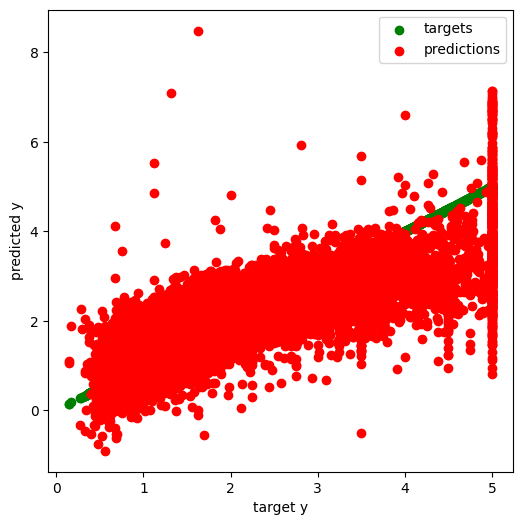

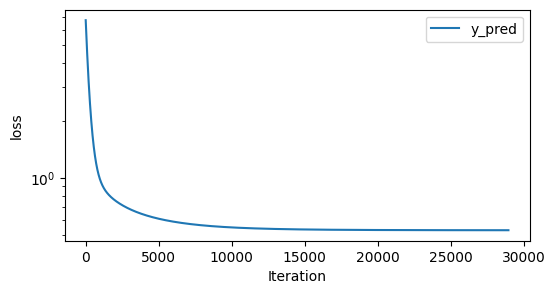

In [13]:
theta = torch.rand(1, X.shape[1] + 1).requires_grad_()

theta_opt, loss_value = train_proc(X_train, theta, y_train,
                                   forward_fcn=linear_regression, lr=0.001, batch_size=64, num_iter=150)

y_train_pred = linear_regression(X_train, theta_opt)
mse_opt = loss_func(y_train, y_train_pred)
print('MSE optimal = %.5f' % mse_opt.item())

plot_peds_vs_targets(y_train, y_train_pred)
plot_loss(loss_value)

**5.** Реализуйте поиск шага обучения по валидации. При каждом новом цикле обучения заново инициализируйте веса модели.

In [14]:
lr = [0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]
batch_size = [16, 32, 64, 128, 256]

best_mse = None
best_lr = None
best_batch_size = None

for lr_step in lr:
  for batch_step in batch_size:
    theta = torch.rand(1, X.shape[1] + 1).requires_grad_()
    theta_opt, loss_value = train_proc(X_train, theta, y_train,
                                   forward_fcn=linear_regression, lr=lr_step, batch_size=batch_step, num_iter=150)
    y_val_pred = linear_regression(X_val, theta_opt)
    mse = loss_func(y_val, y_val_pred)

    print(f"Learning rate: {lr_step}, batch size: {batch_step}\nVal MSE = {mse}")

    if best_mse is None or mse < best_mse:
        best_mse = mse
        best_lr = lr_step
        best_batch_size = batch_step


print(f"Best parameters:\nLearning rate: {best_lr}, batch size: {best_batch_size} with Val MSE = {best_mse:.5f}")

Learning rate: 5e-05, batch size: 16
Val MSE = 0.5505468781992303
Learning rate: 5e-05, batch size: 32
Val MSE = 0.7483124311666863
Learning rate: 5e-05, batch size: 64
Val MSE = 0.7163712368743904
Learning rate: 5e-05, batch size: 128
Val MSE = 2.4032766605553357
Learning rate: 5e-05, batch size: 256
Val MSE = 1.726875083500088
Learning rate: 0.0001, batch size: 16
Val MSE = 0.5152395042017588
Learning rate: 0.0001, batch size: 32
Val MSE = 0.5571700874320661
Learning rate: 0.0001, batch size: 64
Val MSE = 0.6456186736132574
Learning rate: 0.0001, batch size: 128
Val MSE = 0.6991268360738643
Learning rate: 0.0001, batch size: 256
Val MSE = 1.7450222858013913
Learning rate: 0.0005, batch size: 16
Val MSE = 0.5107562127757574
Learning rate: 0.0005, batch size: 32
Val MSE = 0.5103874014799415
Learning rate: 0.0005, batch size: 64
Val MSE = 0.513131724069232
Learning rate: 0.0005, batch size: 128
Val MSE = 0.547405034131435
Learning rate: 0.0005, batch size: 256
Val MSE = 0.60015909347522

**6.** Обучите модель с лучшими параметрами. Выполните оценку и визуализацию работы модели. Для визуализации сделайте пересчет предсказаний в оригинальный масштаб используя обратную нормализацию. Необходимые значения для обратной нормализации можно получить на этапе нормализации.

Train MSE = 0.52831


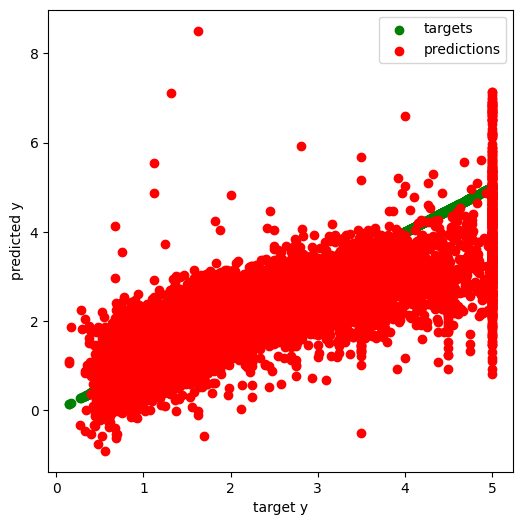

Val MSE = 0.51028


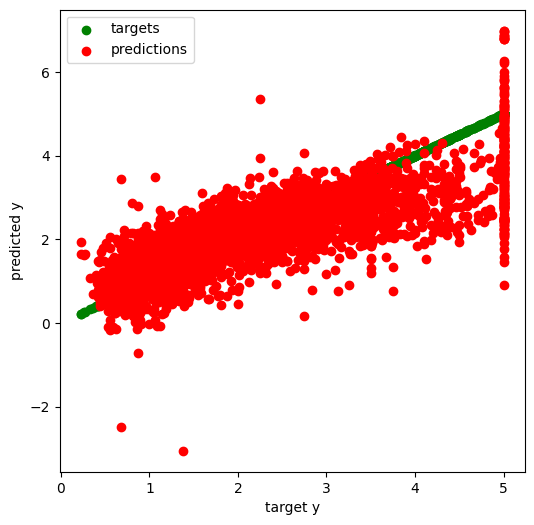

Test MSE = 0.53240


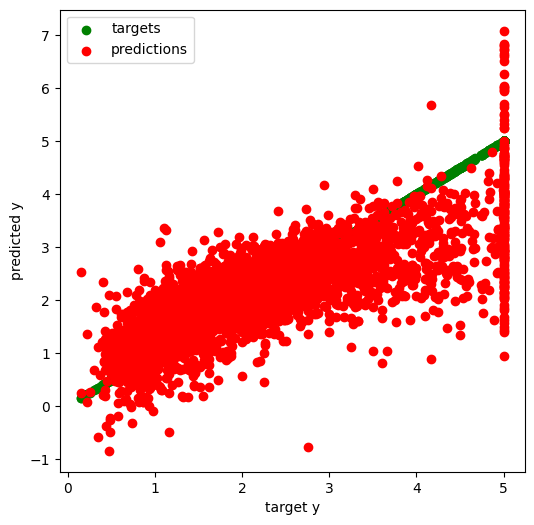

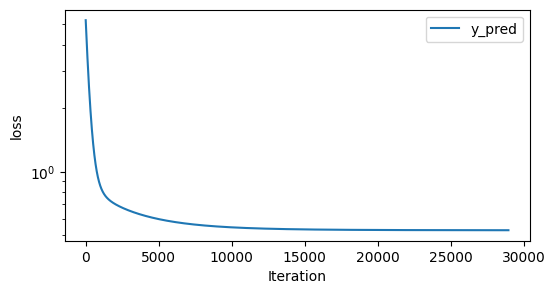

In [15]:

theta = torch.rand(1, X.shape[1] + 1).requires_grad_()
theta_best, loss_value = train_proc(X_train, theta, y_train,
                                   forward_fcn=linear_regression, lr=best_lr, batch_size=best_batch_size, num_iter=150)

y_train_pred = linear_regression(X_train, theta_best)
train_mse = loss_func(y_train, y_train_pred)
print('Train MSE = %.5f' % train_mse.item())
plot_peds_vs_targets(y_train, y_train_pred)

y_val_pred = linear_regression(X_val, theta_best)
val_mse = loss_func(y_val, y_val_pred)
print('Val MSE = %.5f' % val_mse.item())
plot_peds_vs_targets(y_val, y_val_pred)

y_test_pred = linear_regression(X_test, theta_best)
test_mse = loss_func(y_test, y_test_pred)
print('Test MSE = %.5f' % test_mse.item())
plot_peds_vs_targets(y_test, y_test_pred)

plot_loss(loss_value)